# 11 - Optimización de Hiperparámetros del Riesgo Operacional

## Clasificación y regresión final

En este notebook se optimizan los modelos finales del proyecto usando `dataset_modelo_v3.csv`.

Se trabajan dos enfoques conectados:

1. **Clasificación:** `riesgo_operacional_alto`  
   Responde: ¿este envío tiene alto riesgo operacional?

2. **Regresión:** `riesgo_operacional`  
   Responde: ¿cuál es el nivel numérico estimado de riesgo operacional?

La clasificación entrega una alerta operativa, mientras que la regresión entrega un puntaje continuo para priorizar envíos.


# 1. Importación de librerías

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, KFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsRegressor

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", None)


# 2. Carga del dataset V3

In [2]:
df = pd.read_csv("data/05_model_input/dataset_modelo_v3.csv")

print("Dimensiones:", df.shape)
df.head()


Dimensiones: (998, 56)


,id_envio,fecha_envio,id_ruta,id_vehiculo,peso_kg,volumen_m3,tipo_carga,estado,fecha_entrega,origen,destino,distancia_km,tiempo_estimado_hrs,tipo_via,peaje_total,placa,tipo,capacidad_kg,capacidad_m3,año_fabricacion,estado_vehiculo,km_recorridos,cantidad_incidencias,costo_total_incidencias,tipo_incidencia_principal,tiene_incidencia,dias_entrega,velocidad_promedio_km_h,uso_capacidad_kg,uso_capacidad_m3,entrega_tardia,peso_kg_original,distancia_km_original,velocidad_promedio_km_h_original,uso_capacidad_kg_original,uso_capacidad_m3_original,uso_capacidad_kg_recalculado,uso_capacidad_m3_recalculado,antiguedad_vehiculo,densidad_carga,riesgo_operacional,riesgo_velocidad,vehiculo_exigido,sobrecarga_kg,ruta_larga,velocidad_alta,vehiculo_riesgoso_estado,via_compleja,peso_kg_log,distancia_km_log,volumen_m3_log,velocidad_promedio_km_h_log,densidad_carga_log,riesgo_operacional_log,riesgo_velocidad_log,km_recorridos_log
0,1.0,2023-01-01,39.0,46.0,12675.8,28.48,peligrosa,entregado,2023-01-05,valparaíso,chillán,919.3,16.7,urbana,1950.0,ouuc-52,camión,10000.0,20.5,2022.0,en mantención,17043.0,0.0,0.0,sin incidencia,0.0,4.0,55.047904,1.26758,1.389268,1,12675.8,919.3,55.047904,1.26758,1.389268,1.26758,1.389268,4.0,445.061620,1165.286294,50605.538323,1,1,0,0,1,0,9.447529,6.824700,3.383712,4.026207,6.100457,7.061580,10.831836,9.743554
1,2.0,NaN,3.0,27.0,13.6,24.93,peligrosa,entregado,2023-01-05,rancagua,rengo,679.6,18.4,urbana,2447.0,fgkf-38,van,1000.0,22.1,2010.0,operativo,88004.0,0.0,0.0,sin incidencia,0.0,7.0,36.934783,0.01360,1.128054,1,13.6,679.6,36.934783,0.01360,1.128054,0.01360,1.128054,16.0,0.545506,9.242560,25100.878261,0,0,0,0,0,0,2.681022,6.522975,3.255401,3.635868,0.435351,2.326552,10.130698,11.385149
2,3.0,2023-01-02,73.0,18.0,2536.0,50.55,refrigerada,entregado,NaN,maipú,san antonio,468.4,5.2,ruta nacional,11768.0,agdn-22,furgón,20000.0,38.9,2023.0,en mantención,243705.0,0.0,0.0,sin incidencia,0.0,7.0,90.076923,0.12680,1.299486,1,2536.0,468.4,90.076923,0.12680,1.299486,0.12680,1.299486,3.0,50.167158,59.393120,42192.030769,0,0,0,0,1,1,7.838738,6.151455,3.942552,4.511704,3.935098,4.100875,10.650010,12.403718
3,4.0,2023-01-03,49.0,45.0,466.0,13.88,peligrosa,en tránsito,2023-01-07,las condes,osorno,1642.4,18.9,ruta nacional,7202.0,ialh-88,van,1000.0,25.3,2015.0,operativo,224573.5,1.0,1747372.0,desvío de ruta,1.0,4.0,86.899471,0.46600,0.548617,1,466.0,1642.4,86.899471,0.46600,0.548617,0.46600,0.548617,11.0,33.571068,765.358400,142723.691005,0,0,1,0,0,1,6.146329,7.404523,2.700018,4.476194,3.543017,6.641650,11.868673,12.321963
4,5.0,NaN,17.0,36.0,4928.9,0.44,refrigerada,retrasado,2023-01-07,maipú,rancagua,1556.6,17.9,urbana,3799.0,glfy-29,camioneta,5000.0,49.1,2023.0,operativo,138259.0,0.0,0.0,sin incidencia,0.0,7.0,86.960894,0.98578,0.008961,1,4928.9,1556.6,86.960894,0.98578,0.008961,0.98578,0.008961,3.0,11176.643991,1534.465148,135363.327374,1,0,1,0,0,0,8.503074,7.350901,0.364643,4.476892,9.321671,7.336589,11.815725,11.836891


# 3. Creación del target de clasificación

Se define `riesgo_operacional_alto` usando el percentil 75 del riesgo operacional.  
Esto marca como alto riesgo al 25% de los envíos con mayor score.


In [3]:
percentil_riesgo = df["riesgo_operacional"].quantile(0.75)

df["riesgo_operacional_alto"] = np.where(
    df["riesgo_operacional"] >= percentil_riesgo,
    1,
    0
)

print("Umbral de alto riesgo:", percentil_riesgo)

print("\nDistribución del target:")
print(df["riesgo_operacional_alto"].value_counts())
print(df["riesgo_operacional_alto"].value_counts(normalize=True) * 100)


Umbral de alto riesgo: 2279.9541040000004

Distribución del target:
riesgo_operacional_alto
0    755
1    243
Name: count, dtype: int64
riesgo_operacional_alto
0    75.651303
1    24.348697
Name: proportion, dtype: float64


# 4. Variables predictoras

Se usan variables operacionales, de capacidad, velocidad, ruta y transformaciones logarítmicas.  
No se incluye `riesgo_operacional` como predictor de clasificación para evitar fuga directa de información.


In [4]:
variables_base = [
    "distancia_km",
    "tiempo_estimado_hrs",
    "peso_kg",
    "volumen_m3",
    "capacidad_kg",
    "capacidad_m3",
    "velocidad_promedio_km_h",
    "km_recorridos",
    "tipo_via",
    "tipo_carga",
    "estado_vehiculo",
    "tipo",
    "uso_capacidad_kg",
    "uso_capacidad_m3",
    "uso_capacidad_kg_recalculado",
    "uso_capacidad_m3_recalculado",
    "antiguedad_vehiculo",
    "densidad_carga",
    "riesgo_velocidad",
    "vehiculo_exigido",
    "sobrecarga_kg",
    "ruta_larga",
    "velocidad_alta",
    "vehiculo_riesgoso_estado",
    "via_compleja",
    "peso_kg_log",
    "distancia_km_log",
    "volumen_m3_log",
    "velocidad_promedio_km_h_log",
    "densidad_carga_log",
    "riesgo_velocidad_log",
    "km_recorridos_log"
]

variables_modelo = [c for c in variables_base if c in df.columns]

print("Cantidad de variables:", len(variables_modelo))
print(variables_modelo)


Cantidad de variables: 32
['distancia_km', 'tiempo_estimado_hrs', 'peso_kg', 'volumen_m3', 'capacidad_kg', 'capacidad_m3', 'velocidad_promedio_km_h', 'km_recorridos', 'tipo_via', 'tipo_carga', 'estado_vehiculo', 'tipo', 'uso_capacidad_kg', 'uso_capacidad_m3', 'uso_capacidad_kg_recalculado', 'uso_capacidad_m3_recalculado', 'antiguedad_vehiculo', 'densidad_carga', 'riesgo_velocidad', 'vehiculo_exigido', 'sobrecarga_kg', 'ruta_larga', 'velocidad_alta', 'vehiculo_riesgoso_estado', 'via_compleja', 'peso_kg_log', 'distancia_km_log', 'volumen_m3_log', 'velocidad_promedio_km_h_log', 'densidad_carga_log', 'riesgo_velocidad_log', 'km_recorridos_log']


# 5. Preprocesamiento común

In [5]:
X_base = df[variables_modelo].copy()

variables_numericas = X_base.select_dtypes(include=np.number).columns.tolist()
variables_categoricas = X_base.select_dtypes(exclude=np.number).columns.tolist()

transformador_numerico = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

transformador_categorico = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocesador = ColumnTransformer([
    ("num", transformador_numerico, variables_numericas),
    ("cat", transformador_categorico, variables_categoricas)
])

print("Numéricas:", len(variables_numericas))
print("Categóricas:", len(variables_categoricas))


Numéricas: 28
Categóricas: 4


# 6. Funciones de evaluación

In [6]:
def evaluar_clasificacion(nombre_modelo, modelo, X_test, y_test):
    y_pred = modelo.predict(X_test)

    resultado = {
        "modelo": nombre_modelo,
        "accuracy": accuracy_score(y_test, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1_score": f1_score(y_test, y_pred, zero_division=0)
    }

    print(f"===== {nombre_modelo} =====")
    print(pd.Series(resultado))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))

    matriz = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=matriz)
    disp.plot()
    plt.title(f"Matriz de confusión - {nombre_modelo}")
    plt.show()

    return resultado


def evaluar_regresion(nombre_modelo, modelo, X_test, y_test):
    y_pred = modelo.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    resultado = {
        "modelo": nombre_modelo,
        "mae": mean_absolute_error(y_test, y_pred),
        "rmse": rmse,
        "r2": r2_score(y_test, y_pred)
    }

    print(f"===== {nombre_modelo} =====")
    print(pd.Series(resultado))

    comparacion = pd.DataFrame({
        "Real": y_test.values,
        "Predicción": y_pred
    }).head(10)

    display(comparacion)

    return resultado


# 7. Clasificación: modelo base y optimización

## Target: `riesgo_operacional_alto`

Se optimizan:

- Random Forest Classifier;
- Decision Tree Classifier;
- SVM.

La métrica principal será `f1`.


In [7]:
X_clf = df[variables_modelo].copy()
y_clf = df["riesgo_operacional_alto"].copy()

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf,
    y_clf,
    test_size=0.2,
    random_state=42,
    stratify=y_clf
)

cv_clf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


## 7.1 Random Forest base

===== Random Forest Base =====
modelo               Random Forest Base
accuracy                           0.98
balanced_accuracy              0.979862
precision                      0.941176
recall                         0.979592
f1_score                           0.96
dtype: object

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.98      0.99       151
           1       0.94      0.98      0.96        49

    accuracy                           0.98       200
   macro avg       0.97      0.98      0.97       200
weighted avg       0.98      0.98      0.98       200



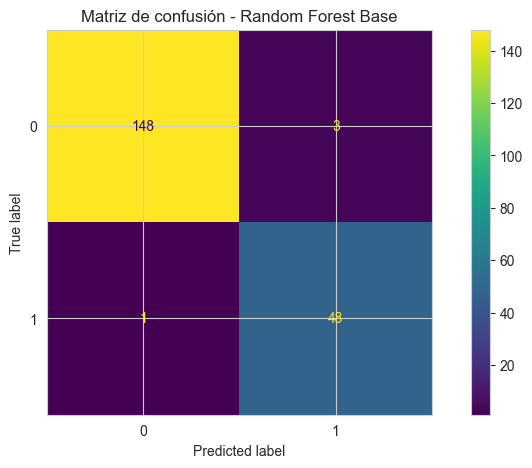

In [8]:
rf_base = Pipeline([
    ("preprocesamiento", preprocesador),
    ("modelo", RandomForestClassifier(
        random_state=42,
        n_estimators=200,
        max_depth=8,
        class_weight="balanced"
    ))
])

rf_base.fit(X_train_clf, y_train_clf)

resultado_rf_base = evaluar_clasificacion(
    "Random Forest Base",
    rf_base,
    X_test_clf,
    y_test_clf
)


## 7.2 Random Forest con GridSearchCV

Mejores parámetros Random Forest:
{'modelo__max_depth': 10, 'modelo__min_samples_leaf': 2, 'modelo__min_samples_split': 2, 'modelo__n_estimators': 100}
Mejor F1 CV: 0.9424767272868537
===== Random Forest GridSearchCV =====
modelo               Random Forest GridSearchCV
accuracy                                   0.98
balanced_accuracy                      0.979862
precision                              0.941176
recall                                 0.979592
f1_score                                   0.96
dtype: object

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.98      0.99       151
           1       0.94      0.98      0.96        49

    accuracy                           0.98       200
   macro avg       0.97      0.98      0.97       200
weighted avg       0.98      0.98      0.98       200



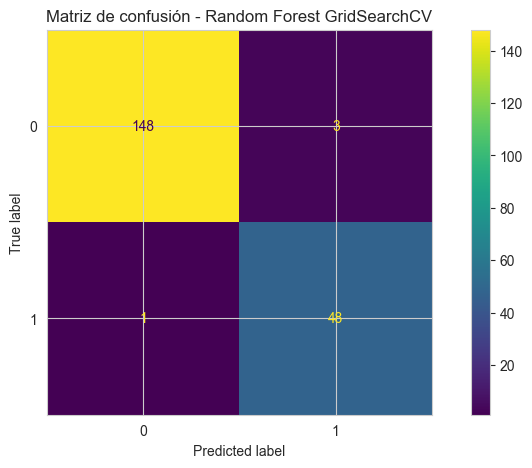

In [9]:
pipeline_rf = Pipeline([
    ("preprocesamiento", preprocesador),
    ("modelo", RandomForestClassifier(
        random_state=42,
        class_weight="balanced"
    ))
])

param_grid_rf = {
    "modelo__n_estimators": [100, 200, 300],
    "modelo__max_depth": [6, 8, 10, None],
    "modelo__min_samples_split": [2, 5, 10],
    "modelo__min_samples_leaf": [1, 2, 4]
}

grid_rf = GridSearchCV(
    pipeline_rf,
    param_grid_rf,
    scoring="f1",
    cv=cv_clf,
    n_jobs=-1
)

grid_rf.fit(X_train_clf, y_train_clf)

print("Mejores parámetros Random Forest:")
print(grid_rf.best_params_)
print("Mejor F1 CV:", grid_rf.best_score_)

rf_grid = grid_rf.best_estimator_

resultado_rf_grid = evaluar_clasificacion(
    "Random Forest GridSearchCV",
    rf_grid,
    X_test_clf,
    y_test_clf
)


## 7.3 Decision Tree con GridSearchCV

Mejores parámetros Decision Tree:
{'modelo__criterion': 'entropy', 'modelo__max_depth': 8, 'modelo__min_samples_leaf': 1, 'modelo__min_samples_split': 2}
Mejor F1 CV: 0.9406949942234496
===== Decision Tree GridSearchCV =====
modelo               Decision Tree GridSearchCV
accuracy                                  0.985
balanced_accuracy                      0.976281
precision                              0.979167
recall                                 0.959184
f1_score                               0.969072
dtype: object

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       151
           1       0.98      0.96      0.97        49

    accuracy                           0.98       200
   macro avg       0.98      0.98      0.98       200
weighted avg       0.98      0.98      0.98       200



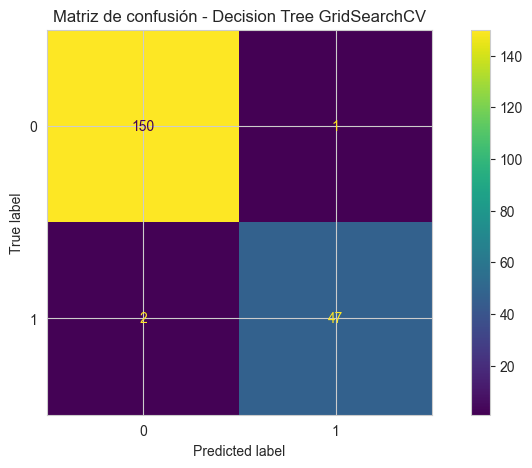

In [10]:
pipeline_tree = Pipeline([
    ("preprocesamiento", preprocesador),
    ("modelo", DecisionTreeClassifier(
        random_state=42,
        class_weight="balanced"
    ))
])

param_grid_tree = {
    "modelo__max_depth": [3, 5, 6, 8, 10, None],
    "modelo__min_samples_split": [2, 5, 10, 20],
    "modelo__min_samples_leaf": [1, 2, 4, 8],
    "modelo__criterion": ["gini", "entropy"]
}

grid_tree = GridSearchCV(
    pipeline_tree,
    param_grid_tree,
    scoring="f1",
    cv=cv_clf,
    n_jobs=-1
)

grid_tree.fit(X_train_clf, y_train_clf)

print("Mejores parámetros Decision Tree:")
print(grid_tree.best_params_)
print("Mejor F1 CV:", grid_tree.best_score_)

tree_grid = grid_tree.best_estimator_

resultado_tree_grid = evaluar_clasificacion(
    "Decision Tree GridSearchCV",
    tree_grid,
    X_test_clf,
    y_test_clf
)


## 7.4 SVM con GridSearchCV

Mejores parámetros SVM:
{'modelo__C': 10, 'modelo__gamma': 'auto', 'modelo__kernel': 'rbf'}
Mejor F1 CV: 0.9265072017318486
===== SVM GridSearchCV =====
modelo               SVM GridSearchCV
accuracy                        0.945
balanced_accuracy            0.942898
precision                    0.851852
recall                       0.938776
f1_score                     0.893204
dtype: object

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.95      0.96       151
           1       0.85      0.94      0.89        49

    accuracy                           0.94       200
   macro avg       0.92      0.94      0.93       200
weighted avg       0.95      0.94      0.95       200



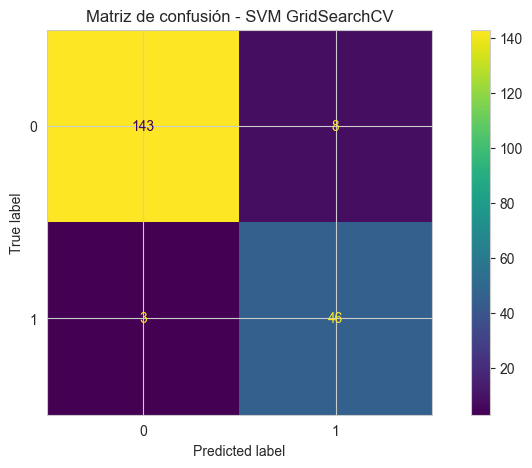

In [11]:
pipeline_svm = Pipeline([
    ("preprocesamiento", preprocesador),
    ("modelo", SVC(
        class_weight="balanced",
        probability=True
    ))
])

param_grid_svm = {
    "modelo__C": [0.1, 1, 10],
    "modelo__kernel": ["linear", "rbf"],
    "modelo__gamma": ["scale", "auto"]
}

grid_svm = GridSearchCV(
    pipeline_svm,
    param_grid_svm,
    scoring="f1",
    cv=cv_clf,
    n_jobs=-1
)

grid_svm.fit(X_train_clf, y_train_clf)

print("Mejores parámetros SVM:")
print(grid_svm.best_params_)
print("Mejor F1 CV:", grid_svm.best_score_)

svm_grid = grid_svm.best_estimator_

resultado_svm_grid = evaluar_clasificacion(
    "SVM GridSearchCV",
    svm_grid,
    X_test_clf,
    y_test_clf
)


## 7.5 Comparación final de clasificación

In [12]:
resultados_clasificacion = pd.DataFrame([
    resultado_rf_base,
    resultado_rf_grid,
    resultado_tree_grid,
    resultado_svm_grid
])

resultados_clasificacion.sort_values(by="f1_score", ascending=False)


,modelo,accuracy,balanced_accuracy,precision,recall,f1_score
2,Decision Tree GridSearchCV,0.985,0.976281,0.979167,0.959184,0.969072
0,Random Forest Base,0.980,0.979862,0.941176,0.979592,0.960000
1,Random Forest GridSearchCV,0.980,0.979862,0.941176,0.979592,0.960000
3,SVM GridSearchCV,0.945,0.942898,0.851852,0.938776,0.893204


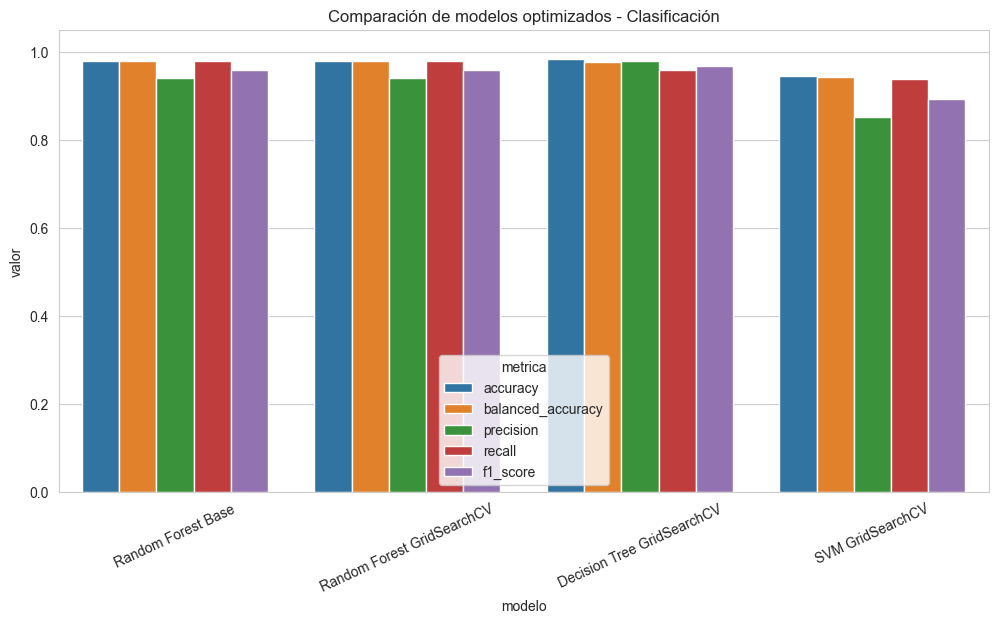

In [13]:
tabla_melt = resultados_clasificacion.melt(
    id_vars="modelo",
    value_vars=["accuracy", "balanced_accuracy", "precision", "recall", "f1_score"],
    var_name="metrica",
    value_name="valor"
)

plt.figure(figsize=(12,6))
sns.barplot(data=tabla_melt, x="modelo", y="valor", hue="metrica")
plt.title("Comparación de modelos optimizados - Clasificación")
plt.xticks(rotation=25)
plt.ylim(0, 1.05)
plt.show()


## 7.6 Importancia de variables del mejor clasificador

Mejor modelo clasificación: Decision Tree GridSearchCV



modelo               Decision Tree GridSearchCV
accuracy                                  0.985
balanced_accuracy                      0.976281
precision                              0.979167
recall                                 0.959184
f1_score                               0.969072
Name: 2, dtype: object

,variable,importancia
8,num__uso_capacidad_kg,5.382266e-01
22,num__distancia_km_log,2.159867e-01
0,num__distancia_km,1.216844e-01
10,num__uso_capacidad_kg_recalculado,6.856567e-02
14,num__riesgo_velocidad,3.170760e-02
1,num__tiempo_estimado_hrs,1.287585e-02
17,num__ruta_larga,6.051612e-03
9,num__uso_capacidad_m3,4.901611e-03
28,cat__tipo_via_autopista,7.398642e-17
42,cat__tipo_furgón,3.977765e-17


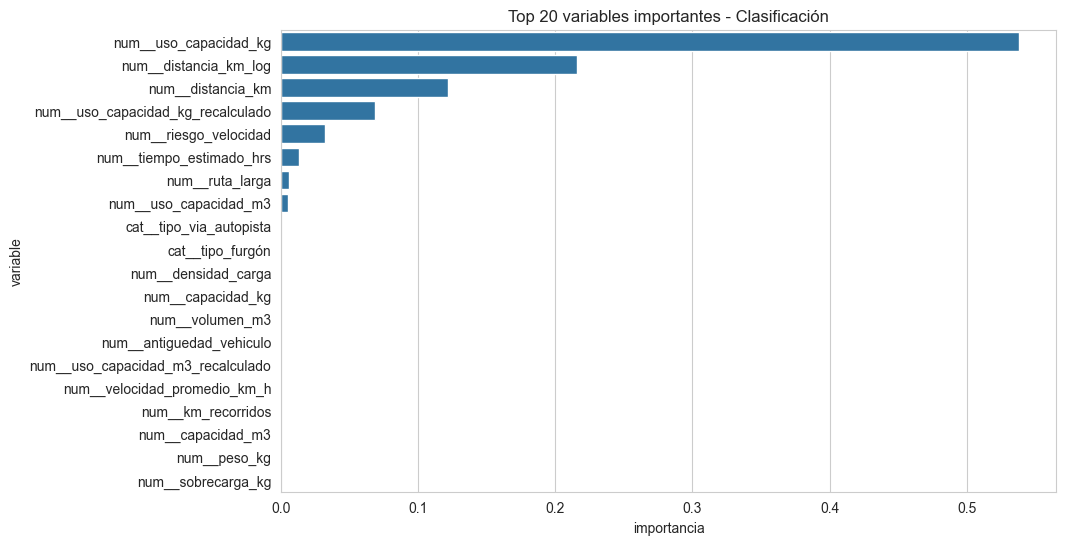

In [14]:
mejor_clf = resultados_clasificacion.sort_values(
    by="f1_score",
    ascending=False
).iloc[0]

nombre_mejor_clf = mejor_clf["modelo"]

modelos_clf = {
    "Random Forest Base": rf_base,
    "Random Forest GridSearchCV": rf_grid,
    "Decision Tree GridSearchCV": tree_grid,
    "SVM GridSearchCV": svm_grid
}

modelo_mejor_clf = modelos_clf[nombre_mejor_clf]

print("Mejor modelo clasificación:", nombre_mejor_clf)
display(mejor_clf)

try:
    modelo_arbol = modelo_mejor_clf.named_steps["modelo"]
    prep = modelo_mejor_clf.named_steps["preprocesamiento"]

    if hasattr(modelo_arbol, "feature_importances_"):
        nombres_features = prep.get_feature_names_out()

        importancias = pd.DataFrame({
            "variable": nombres_features,
            "importancia": modelo_arbol.feature_importances_
        }).sort_values(by="importancia", ascending=False)

        display(importancias.head(20))

        plt.figure(figsize=(10,6))
        sns.barplot(data=importancias.head(20), x="importancia", y="variable")
        plt.title("Top 20 variables importantes - Clasificación")
        plt.show()
    else:
        print("El modelo seleccionado no tiene feature_importances_.")

except Exception as e:
    print("No fue posible calcular importancias:", e)


# 8. Regresión: modelo base y optimización

## Target: `riesgo_operacional`

Se optimizan:

- Random Forest Regressor;
- Decision Tree Regressor;
- KNN Regressor.

La métrica principal de optimización será `neg_root_mean_squared_error`, equivalente a minimizar RMSE.


In [15]:
X_reg = df[variables_modelo].copy()
y_reg = df["riesgo_operacional"].copy()

datos_reg = pd.concat([X_reg, y_reg], axis=1).dropna(subset=["riesgo_operacional"])

X_reg = datos_reg[variables_modelo]
y_reg = datos_reg["riesgo_operacional"]

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42
)

cv_reg = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("Registros usados en regresión:", X_reg.shape[0])


Registros usados en regresión: 971


## 8.1 Random Forest Regressor base

In [16]:
rf_reg_base = Pipeline([
    ("preprocesamiento", preprocesador),
    ("modelo", RandomForestRegressor(
        random_state=42,
        n_estimators=200,
        max_depth=8
    ))
])

rf_reg_base.fit(X_train_reg, y_train_reg)

resultado_rf_reg_base = evaluar_regresion(
    "Random Forest Regressor Base",
    rf_reg_base,
    X_test_reg,
    y_test_reg
)


===== Random Forest Regressor Base =====
modelo    Random Forest Regressor Base
mae                          59.073087
rmse                        131.484784
r2                            0.994829
dtype: object


,Real,Predicción
0,8128.500000,8070.800643
1,6359.600000,6861.645231
2,372.049662,391.073291
3,874.370650,890.581552
4,1746.921410,1772.632872
5,2332.587290,2281.709692
6,49.100064,74.246619
7,604.078135,676.225336
8,128.747382,131.091177
9,317.646684,325.597231


## 8.2 Random Forest Regressor con GridSearchCV

In [17]:
pipeline_rf_reg = Pipeline([
    ("preprocesamiento", preprocesador),
    ("modelo", RandomForestRegressor(random_state=42))
])

param_grid_rf_reg = {
    "modelo__n_estimators": [100, 200, 300],
    "modelo__max_depth": [6, 8, 10, None],
    "modelo__min_samples_split": [2, 5, 10],
    "modelo__min_samples_leaf": [1, 2, 4]
}

grid_rf_reg = GridSearchCV(
    pipeline_rf_reg,
    param_grid_rf_reg,
    scoring="neg_root_mean_squared_error",
    cv=cv_reg,
    n_jobs=-1
)

grid_rf_reg.fit(X_train_reg, y_train_reg)

print("Mejores parámetros Random Forest Regressor:")
print(grid_rf_reg.best_params_)
print("Mejor RMSE CV:", abs(grid_rf_reg.best_score_))

rf_reg_grid = grid_rf_reg.best_estimator_

resultado_rf_reg_grid = evaluar_regresion(
    "Random Forest Regressor GridSearchCV",
    rf_reg_grid,
    X_test_reg,
    y_test_reg
)


Mejores parámetros Random Forest Regressor:
{'modelo__max_depth': None, 'modelo__min_samples_leaf': 1, 'modelo__min_samples_split': 2, 'modelo__n_estimators': 100}
Mejor RMSE CV: 282.636457732133
===== Random Forest Regressor GridSearchCV =====
modelo    Random Forest Regressor GridSearchCV
mae                                  56.390841
rmse                                130.958201
r2                                    0.994871
dtype: object


,Real,Predicción
0,8128.500000,8100.546416
1,6359.600000,6938.531979
2,372.049662,372.527805
3,874.370650,866.278802
4,1746.921410,1732.032223
5,2332.587290,2291.767082
6,49.100064,81.292858
7,604.078135,705.156277
8,128.747382,134.477623
9,317.646684,324.730013


## 8.3 Decision Tree Regressor con GridSearchCV

In [18]:
pipeline_tree_reg = Pipeline([
    ("preprocesamiento", preprocesador),
    ("modelo", DecisionTreeRegressor(random_state=42))
])

param_grid_tree_reg = {
    "modelo__max_depth": [3, 5, 6, 8, 10, None],
    "modelo__min_samples_split": [2, 5, 10, 20],
    "modelo__min_samples_leaf": [1, 2, 4, 8]
}

grid_tree_reg = GridSearchCV(
    pipeline_tree_reg,
    param_grid_tree_reg,
    scoring="neg_root_mean_squared_error",
    cv=cv_reg,
    n_jobs=-1
)

grid_tree_reg.fit(X_train_reg, y_train_reg)

print("Mejores parámetros Decision Tree Regressor:")
print(grid_tree_reg.best_params_)
print("Mejor RMSE CV:", abs(grid_tree_reg.best_score_))

tree_reg_grid = grid_tree_reg.best_estimator_

resultado_tree_reg_grid = evaluar_regresion(
    "Decision Tree Regressor GridSearchCV",
    tree_reg_grid,
    X_test_reg,
    y_test_reg
)


Mejores parámetros Decision Tree Regressor:
{'modelo__max_depth': 10, 'modelo__min_samples_leaf': 1, 'modelo__min_samples_split': 2}
Mejor RMSE CV: 325.07930395397193
===== Decision Tree Regressor GridSearchCV =====
modelo    Decision Tree Regressor GridSearchCV
mae                                 105.131155
rmse                                194.656646
r2                                    0.988667
dtype: object


,Real,Predicción
0,8128.500000,8146.166667
1,6359.600000,6421.472803
2,372.049662,375.914096
3,874.370650,847.913060
4,1746.921410,1823.860671
5,2332.587290,2085.398776
6,49.100064,45.671184
7,604.078135,631.916557
8,128.747382,138.246520
9,317.646684,300.782491


## 8.4 KNN Regressor con GridSearchCV

In [19]:
pipeline_knn_reg = Pipeline([
    ("preprocesamiento", preprocesador),
    ("modelo", KNeighborsRegressor())
])

param_grid_knn_reg = {
    "modelo__n_neighbors": [3, 5, 7, 9, 11],
    "modelo__weights": ["uniform", "distance"],
    "modelo__p": [1, 2]
}

grid_knn_reg = GridSearchCV(
    pipeline_knn_reg,
    param_grid_knn_reg,
    scoring="neg_root_mean_squared_error",
    cv=cv_reg,
    n_jobs=-1
)

grid_knn_reg.fit(X_train_reg, y_train_reg)

print("Mejores parámetros KNN Regressor:")
print(grid_knn_reg.best_params_)
print("Mejor RMSE CV:", abs(grid_knn_reg.best_score_))

knn_reg_grid = grid_knn_reg.best_estimator_

resultado_knn_reg_grid = evaluar_regresion(
    "KNN Regressor GridSearchCV",
    knn_reg_grid,
    X_test_reg,
    y_test_reg
)


Mejores parámetros KNN Regressor:
{'modelo__n_neighbors': 5, 'modelo__p': 1, 'modelo__weights': 'distance'}
Mejor RMSE CV: 841.7160504750224
===== KNN Regressor GridSearchCV =====
modelo    KNN Regressor GridSearchCV
mae                       401.262278
rmse                      591.750926
r2                          0.895268
dtype: object


,Real,Predicción
0,8128.500000,7164.830926
1,6359.600000,7868.281943
2,372.049662,450.684356
3,874.370650,1251.426439
4,1746.921410,1341.684527
5,2332.587290,1752.349830
6,49.100064,226.693096
7,604.078135,817.954168
8,128.747382,212.712093
9,317.646684,318.532396


## 8.5 Comparación final de regresión

In [20]:
resultados_regresion = pd.DataFrame([
    resultado_rf_reg_base,
    resultado_rf_reg_grid,
    resultado_tree_reg_grid,
    resultado_knn_reg_grid
])

resultados_regresion.sort_values(by="rmse", ascending=True)


,modelo,mae,rmse,r2
1,Random Forest Regressor GridSearchCV,56.390841,130.958201,0.994871
0,Random Forest Regressor Base,59.073087,131.484784,0.994829
2,Decision Tree Regressor GridSearchCV,105.131155,194.656646,0.988667
3,KNN Regressor GridSearchCV,401.262278,591.750926,0.895268


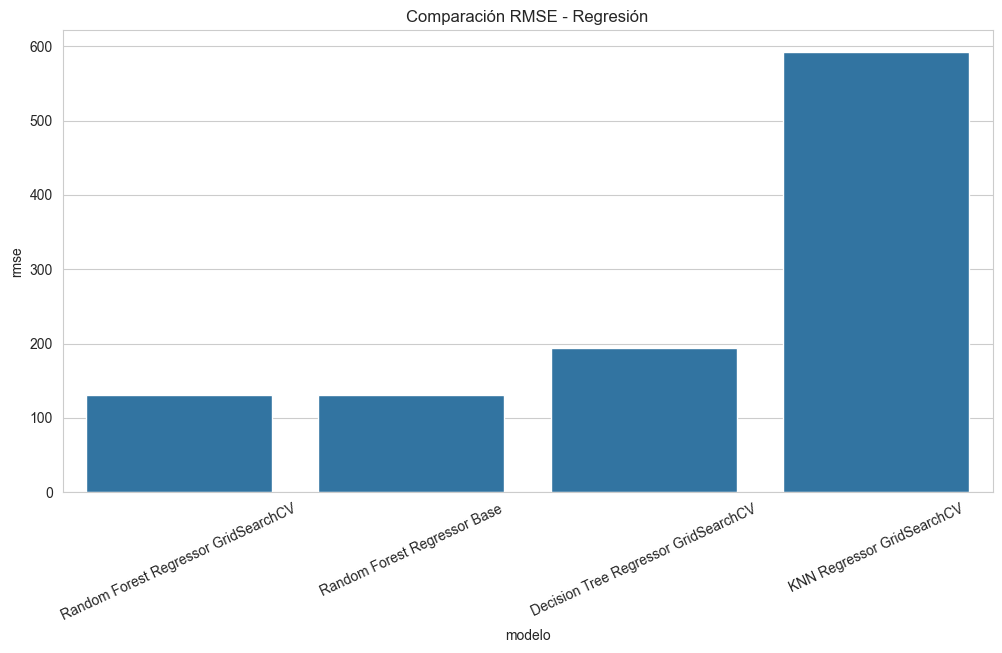

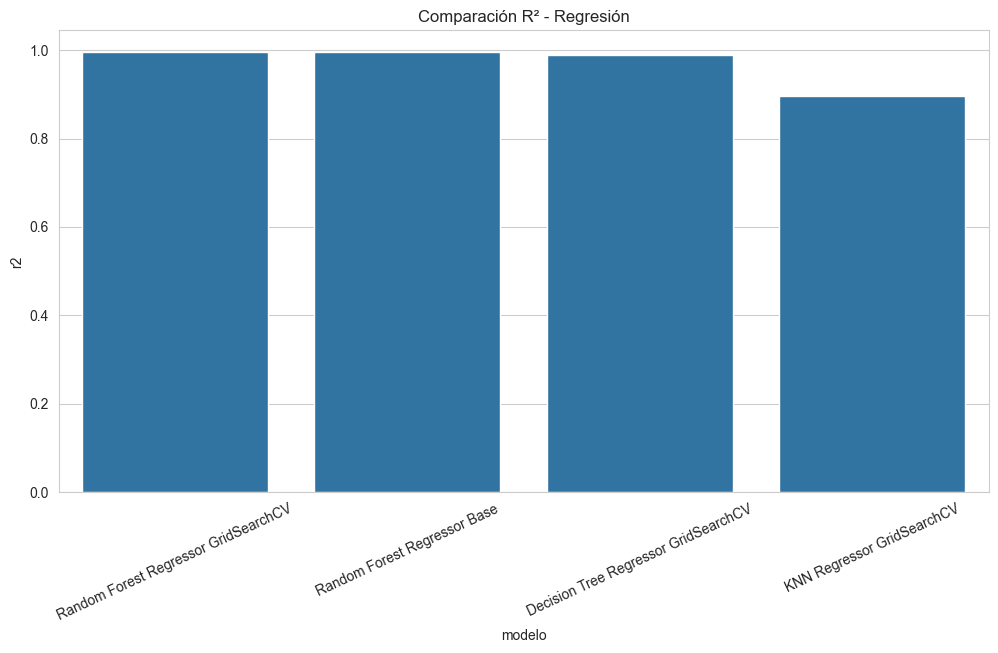

In [21]:
plt.figure(figsize=(12,6))
sns.barplot(
    data=resultados_regresion.sort_values(by="rmse"),
    x="modelo",
    y="rmse"
)
plt.title("Comparación RMSE - Regresión")
plt.xticks(rotation=25)
plt.show()

plt.figure(figsize=(12,6))
sns.barplot(
    data=resultados_regresion.sort_values(by="r2", ascending=False),
    x="modelo",
    y="r2"
)
plt.title("Comparación R² - Regresión")
plt.xticks(rotation=25)
plt.show()


## 8.6 Importancia de variables del mejor regresor

Mejor modelo regresión: Random Forest Regressor GridSearchCV



modelo    Random Forest Regressor GridSearchCV
mae                                  56.390841
rmse                                130.958201
r2                                    0.994871
Name: 1, dtype: object

,variable,importancia
8,num__uso_capacidad_kg,0.375658
22,num__distancia_km_log,0.192362
0,num__distancia_km,0.165697
10,num__uso_capacidad_kg_recalculado,0.152421
14,num__riesgo_velocidad,0.057315
26,num__riesgo_velocidad_log,0.044105
9,num__uso_capacidad_m3,0.001198
11,num__uso_capacidad_m3_recalculado,0.001175
7,num__km_recorridos,0.001167
5,num__capacidad_m3,0.001086


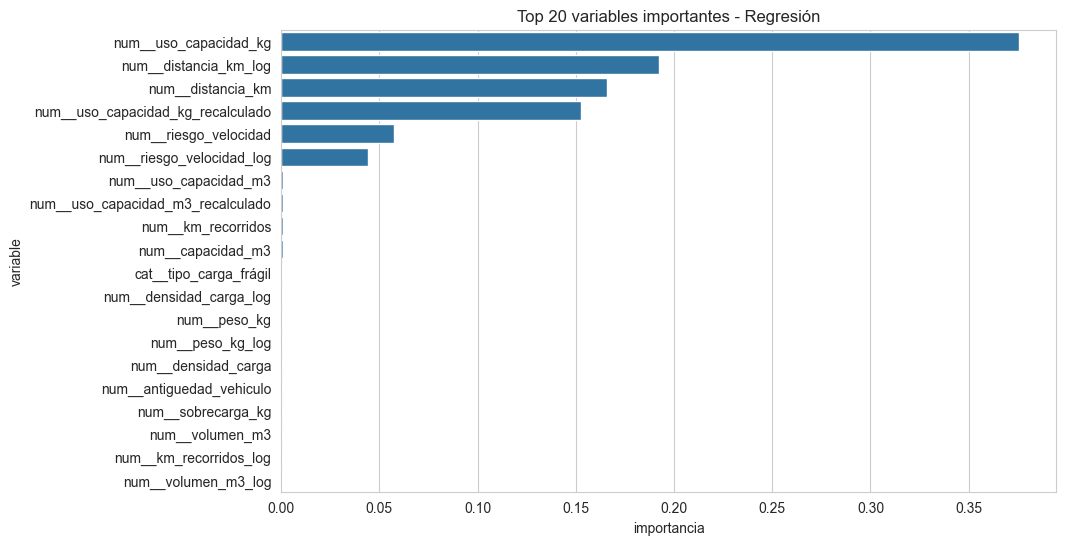

In [22]:
mejor_reg = resultados_regresion.sort_values(
    by="rmse",
    ascending=True
).iloc[0]

nombre_mejor_reg = mejor_reg["modelo"]

modelos_reg = {
    "Random Forest Regressor Base": rf_reg_base,
    "Random Forest Regressor GridSearchCV": rf_reg_grid,
    "Decision Tree Regressor GridSearchCV": tree_reg_grid,
    "KNN Regressor GridSearchCV": knn_reg_grid
}

modelo_mejor_reg = modelos_reg[nombre_mejor_reg]

print("Mejor modelo regresión:", nombre_mejor_reg)
display(mejor_reg)

try:
    modelo_arbol_reg = modelo_mejor_reg.named_steps["modelo"]
    prep_reg = modelo_mejor_reg.named_steps["preprocesamiento"]

    if hasattr(modelo_arbol_reg, "feature_importances_"):
        nombres_features = prep_reg.get_feature_names_out()

        importancias_reg = pd.DataFrame({
            "variable": nombres_features,
            "importancia": modelo_arbol_reg.feature_importances_
        }).sort_values(by="importancia", ascending=False)

        display(importancias_reg.head(20))

        plt.figure(figsize=(10,6))
        sns.barplot(data=importancias_reg.head(20), x="importancia", y="variable")
        plt.title("Top 20 variables importantes - Regresión")
        plt.show()
    else:
        print("El modelo seleccionado no tiene feature_importances_.")

except Exception as e:
    print("No fue posible calcular importancias:", e)


# 9. Resumen final

Se muestran los mejores modelos finales para clasificación y regresión.


In [23]:
print("===== MEJOR MODELO DE CLASIFICACIÓN =====")
display(mejor_clf)

print("\n===== MEJOR MODELO DE REGRESIÓN =====")
display(mejor_reg)


===== MEJOR MODELO DE CLASIFICACIÓN =====



modelo               Decision Tree GridSearchCV
accuracy                                  0.985
balanced_accuracy                      0.976281
precision                              0.979167
recall                                 0.959184
f1_score                               0.969072
Name: 2, dtype: object


===== MEJOR MODELO DE REGRESIÓN =====



modelo    Random Forest Regressor GridSearchCV
mae                                  56.390841
rmse                                130.958201
r2                                    0.994871
Name: 1, dtype: object

# 10. Conclusiones finales

En este notebook se optimizaron los modelos finales del proyecto:

## Clasificación
El modelo de clasificación permite identificar envíos de alto riesgo operacional.  
Esta salida es útil como sistema de alerta temprana.

## Regresión
El modelo de regresión permite estimar el puntaje continuo de riesgo operacional.  
Esta salida es útil para ordenar y priorizar envíos según criticidad.

Ambos modelos están conectados: la regresión calcula la intensidad del riesgo y la clasificación convierte ese riesgo en una decisión operativa simple.
